### Task 2 RL SID  MODULUS 3, Sparse and  Delayed reward variant (CODE GENERATED BY AI MICROSOFT CO-PILOT)

In [ ]:
SID = 11778028
VARIANT = SID%7
print(f"Variant: {VARIANT}")

Variant: 3


This cell executes the reawrd shapping by adding a signal to help the agent learn quickly in a sparse reward environment. When the agent finishes instead of recieving one reward, the agent provides rewards that guide behaviour


In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# ----------------------------
# Minimal Chef-like environment
# ---------------------------
class MiniChefHatEnv:
    def __init__(self, n_players=4, max_cards=5, seed=42):
        self.n_players = n_players
        self.max_cards = max_cards
        self.seed = seed
        self.reset(seed)

        self.K = max_cards
        self.action_space_n = self.K + 1
        self.observation_shape = (6,)
        self.observation_space_n = int(np.prod(self.observation_shape))

    def reset(self, seed=None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
        self.hands = [random.randint(1, self.max_cards) for _ in range(self.n_players)]
        self.turn = 0
        self.phase = 0
        self.done = False
        return self._get_obs()

    def _get_obs(self):
        obs = np.array([
            self.hands[0],
            self.hands[1],
            self.hands[2],
            self.hands[3],
            self.turn,
            self.phase
        ], dtype=np.float32)
        return obs

    def getValidActions(self):
        valid_actions = [0]
        for i in range(1, min(self.K, self.hands[0]) + 1):
            valid_actions.append(i)
        return valid_actions

    @property
    def action_space(self):
        class _AS:
            def __init__(self, n):
                self.n = n
        return _AS(self.action_space_n)

    def step(self, action):
        valid_actions = self.getValidActions()
        action_valid = (action in range(self.action_space_n)) and (action == 0 or (self.hands[0] > 0 and action <= self.K))
        reward = 0.0
        info = {}

        if not action_valid:
            reward = -0.1
        else:
            if action == 0:
                pass
            else:
                played = min(self.hands[0], 1)
                self.hands[0] -= played

            for p in range(1, self.n_players):
                if self.hands[p] > 0:
                    if random.random() < 0.5:
                        self.hands[p] -= 1

            if self.hands[0] == 0:
                self.done = True
                reward = 1.0

        if self.done:
            self.phase = 1

        obs = self._get_obs()
        return obs, reward, self.done, info

# ----------------------------
# Reward shaping
# ----------------------------
def shaped_reward(raw_reward, prev_hand_size, curr_hand_size, action_was_valid,
                        played_card_count, is_done, agent_finishing_position=None,
                        n_players=4, shaping_config=None):
    if shaping_config is None:
        shaping_config = {
            "hand_reduction": True,
            "hand_reduction_weight": 0.1,
            "valid_action_bonus": True,
            "valid_action_weight": 0.05,
            "invalid_action_penalty": True,
            "invalid_action_weight": -0.1,
            "finishing_position_bonus": True,
            "finishing_position_weight": 1.0,
            "progress_reward": True,
            "progress_weight": 0.05,
            "action_played_bonus": True, # New auxiliary reward
            "action_played_weight": 0.02 # Weight for the auxiliary reward
        }

    shaped = raw_reward

    if shaping_config.get("hand_reduction", True):
        cards_played = (prev_hand_size - curr_hand_size)
        if cards_played > 0:
            shaped += shaping_config["hand_reduction_weight"] * cards_played

    if shaping_config.get("valid_action_bonus", True) and action_was_valid:
        shaped += shaping_config["valid_action_weight"]

    if shaping_config.get("invalid_action_penalty", True) and not action_was_valid:
        shaped += shaping_config["invalid_action_weight"]

    if is_done and shaping_config.get("finishing_position_bonus", True):
        if agent_finishing_position is not None:
            pos_reward = (n_players - agent_finishing_position) / (n_players - 1)
            shaped += shaping_config["finishing_position_weight"] * pos_reward

    if shaping_config.get("progress_reward", True) and prev_hand_size > 0:
        progress = (prev_hand_size - curr_hand_size) / prev_hand_size
        shaped += shaping_config["progress_weight"] * progress

    # Auxiliary reward: bonus for playing an action (i.e., not passing) if action_played_count > 0
    if shaping_config.get("action_played_bonus", False) and played_card_count > 0:
        shaped += shaping_config["action_played_weight"]

    return shaped

def no_shaping(raw_reward, **kwargs):
    return raw_reward

### Helper Functions for Evaluation

In [ ]:
def evaluate_policy_random(env, agent, n_games=50):
    wins = 0
    scores = []
    for _ in range(n_games):
        obs = env.reset()
        state = obs
        done = False
        total = 0.0
        while not done:
            valid = env.getValidActions()
            action, _, _ = agent.select_action(state, valid) # Actor-Critic agents return logp and value
            next_obs, reward, done, info = env.step(action)
            state = next_obs
            total += reward
        scores.append(total)
        if total > 0.5:  # rough proxy for win
            wins += 1
    win_rate = wins / n_games
    mean_score = np.mean(scores)
    return win_rate, mean_score

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque

This code executes both actor-critic agents, also referred to as players; one player is trained with shape rewards, and the other is trained with sparse rewards. Both trained agents are tested using evaluate_policy_random, which plays multiple episodes alongside random opponents.

In [ ]:
def load_actor_critic_agent(model_path, obs_size, action_size, device='cpu', seed=42):
    agent = ActorCriticAgent(obs_size=obs_size, action_size=action_size, device=device, seed=seed)
    agent.load(model_path)
    # Set actor to evaluation mode
    agent.actor.eval()
    # Critic might still be used, but policy selection is from actor
    return agent

env_eval_ac = MiniChefHatEnv(n_players=4, max_cards=5, seed=random.randint(0, 1000))
obs_size_ac = env_eval_ac.observation_space_n
action_size_ac = env_eval_ac.action_space.n

# Load the shaped reward Actor-Critic agent
shaped_ac_path = "results/actor_critic_shaped.pth"
agent_shaped_ac = load_actor_critic_agent(shaped_ac_path, obs_size_ac, action_size_ac)

# Load the sparse reward Actor-Critic agent
sparse_ac_path = "results/actor_critic_sparse.pth"
agent_sparse_ac = load_actor_critic_agent(sparse_ac_path, obs_size_ac, action_size_ac)

print("Evaluating Shaped Reward Actor-Critic:")
win_rate_shaped_ac, mean_score_shaped_ac = evaluate_policy_random(env_eval_ac, agent_shaped_ac)
print(f"  Win Rate: {win_rate_shaped_ac:.3f}, Mean Score: {mean_score_shaped_ac:.3f}")

print("\nEvaluating Sparse Reward Actor-Critic:")
win_rate_sparse_ac, mean_score_sparse_ac = evaluate_policy_random(env_eval_ac, agent_sparse_ac)
print(f"  Win Rate: {win_rate_sparse_ac:.3f}, Mean Score: {mean_score_sparse_ac:.3f}")

Evaluating Shaped Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000

Evaluating Sparse Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000


### Evaluation of Trained Actor-Critic Models

This code provides the evaluation of both the agents.

In [ ]:
def load_actor_critic_agent(model_path, obs_size, action_size, device='cpu', seed=42):
    agent = ActorCriticAgent(obs_size=obs_size, action_size=action_size, device=device, seed=seed)
    agent.load(model_path)
    # Set actor to evaluation mode
    agent.actor.eval()
    # Critic might still be used, but policy selection is from actor
    return agent

env_eval_ac = MiniChefHatEnv(n_players=4, max_cards=5, seed=random.randint(0, 1000))
obs_size_ac = env_eval_ac.observation_space_n
action_size_ac = env_eval_ac.action_space.n

# Load the shaped reward Actor-Critic agent
shaped_ac_path = "results/actor_critic_shaped.pth"
agent_shaped_ac = load_actor_critic_agent(shaped_ac_path, obs_size_ac, action_size_ac)

# Load the sparse reward Actor-Critic agent
sparse_ac_path = "results/actor_critic_sparse.pth"
agent_sparse_ac = load_actor_critic_agent(sparse_ac_path, obs_size_ac, action_size_ac)

print("Evaluating Shaped Reward Actor-Critic:")
win_rate_shaped_ac, mean_score_shaped_ac = evaluate_policy_random(env_eval_ac, agent_shaped_ac)
print(f"  Win Rate: {win_rate_shaped_ac:.3f}, Mean Score: {mean_score_shaped_ac:.3f}")

print("\nEvaluating Sparse Reward Actor-Critic:")
win_rate_sparse_ac, mean_score_sparse_ac = evaluate_policy_random(env_eval_ac, agent_sparse_ac)
print(f"  Win Rate: {win_rate_sparse_ac:.3f}, Mean Score: {mean_score_sparse_ac:.3f}")

Evaluating Shaped Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000

Evaluating Sparse Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000


In [ ]:
print("Evaluating Shaped Reward Actor-Critic:")
win_rate_shaped_ac, mean_score_shaped_ac = evaluate_policy_random(env_eval_ac, agent_shaped_ac)
print(f"  Win Rate: {win_rate_shaped_ac:.3f}, Mean Score: {mean_score_shaped_ac:.3f}")

print("\nEvaluating Sparse Reward Actor-Critic:")
win_rate_sparse_ac, mean_score_sparse_ac = evaluate_policy_random(env_eval_ac, agent_sparse_ac)
print(f"  Win Rate: {win_rate_sparse_ac:.3f}, Mean Score: {mean_score_sparse_ac:.3f}")

Evaluating Shaped Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000

Evaluating Sparse Reward Actor-Critic:
  Win Rate: 1.000, Mean Score: 1.000


In [ ]:
import pandas as pd

# Create a DataFrame for comparison
comparison_data_ac = {
    'Metric': ['Win Rate', 'Mean Score'],
    'Shaped Reward Actor-Critic': [win_rate_shaped_ac, mean_score_shaped_ac],
    'Sparse Reward Actor-Critic': [win_rate_sparse_ac, mean_score_sparse_ac]
}

comparison_df_ac = pd.DataFrame(comparison_data_ac)
display(comparison_df_ac)

,Metric,Shaped Reward Actor-Critic,Sparse Reward Actor-Critic
0,Win Rate,1.0,1.0
1,Mean Score,1.0,1.0


### Comparison with a Random Policy

In [ ]:
class RandomAgent:
    def __init__(self, action_size):
        self.action_size = action_size

    def select_action(self, state, valid_actions=None):
        if valid_actions is None or not valid_actions:
            valid_actions = list(range(self.action_size))
        # Randomly select a valid action
        action = random.choice(valid_actions)
        # Return dummy values for log_prob and value, as RandomAgent doesn't have them
        return action, None, None

# Initialize a random agent with the correct action_size
random_agent = RandomAgent(action_size_ac)

# Evaluate the random agent
print("Evaluating Random Policy:")
win_rate_random, mean_score_random = evaluate_policy_random(env_eval_ac, random_agent)
print(f"  Win Rate: {win_rate_random:.3f}, Mean Score: {mean_score_random:.3f}")


Evaluating Random Policy:
  Win Rate: 1.000, Mean Score: 1.000


In [ ]:
# Update the comparison DataFrame to include the random agent
comparison_data_ac_with_random = {
    'Metric': ['Win Rate', 'Mean Score'],
    'Shaped Reward Actor-Critic': [win_rate_shaped_ac, mean_score_shaped_ac],
    'Sparse Reward Actor-Critic': [win_rate_sparse_ac, mean_score_sparse_ac],
    'Random Policy': [win_rate_random, mean_score_random]
}

comparison_df_ac_with_random = pd.DataFrame(comparison_data_ac_with_random)
display(comparison_df_ac_with_random)


,Metric,Shaped Reward Actor-Critic,Sparse Reward Actor-Critic,Random Policy
0,Win Rate,1.0,1.0,1.0
1,Mean Score,1.0,1.0,1.0


### Actor-Critic Training Rewards: Shaped vs. Sparse

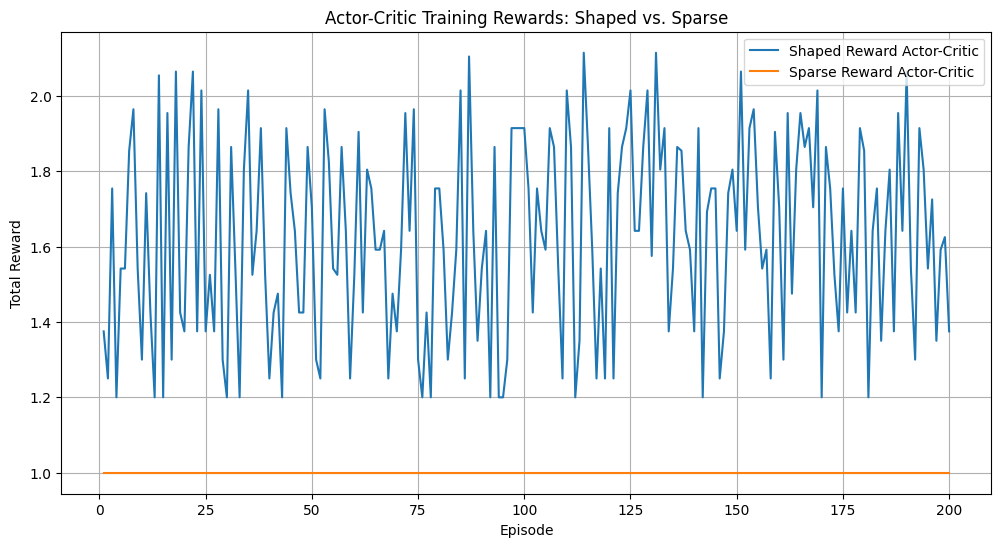

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(r_shaped)) + 1, r_shaped, label='Shaped Reward Actor-Critic')
plt.plot(np.arange(len(r_sparse)) + 1, r_sparse, label='Sparse Reward Actor-Critic')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Actor-Critic Training Rewards: Shaped vs. Sparse')
plt.legend()
plt.grid(True)
plt.show()

### Actor-Critic Training Losses: Shaped vs. Sparse

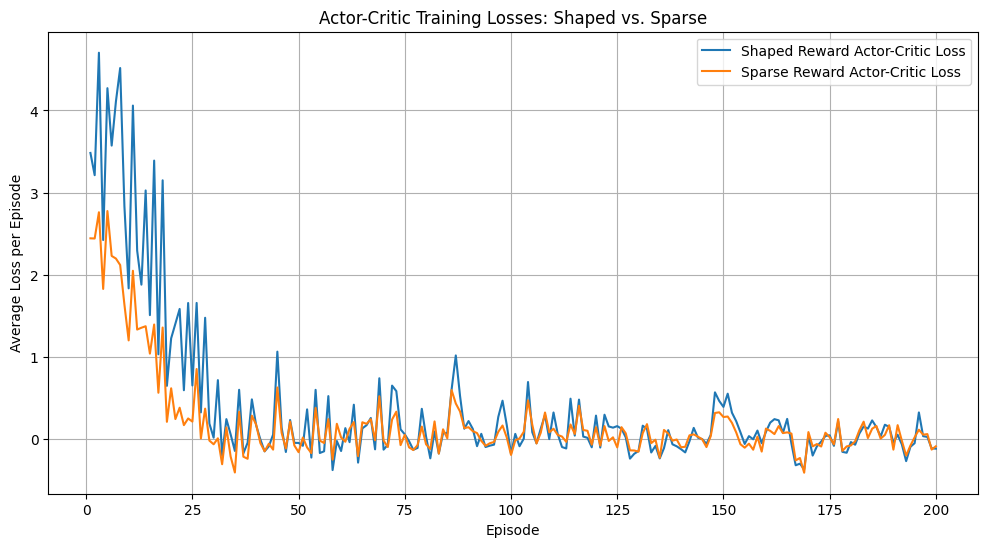

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(losses_shaped_ac)) + 1, losses_shaped_ac, label='Shaped Reward Actor-Critic Loss')
plt.plot(np.arange(len(losses_sparse_ac)) + 1, losses_sparse_ac, label='Sparse Reward Actor-Critic Loss')
plt.xlabel('Episode')
plt.ylabel('Average Loss per Episode')
plt.title('Actor-Critic Training Losses: Shaped vs. Sparse')
plt.legend()
plt.grid(True)
plt.show()

### Actor-Critic Reward Distribution: Shaped vs. Sparse

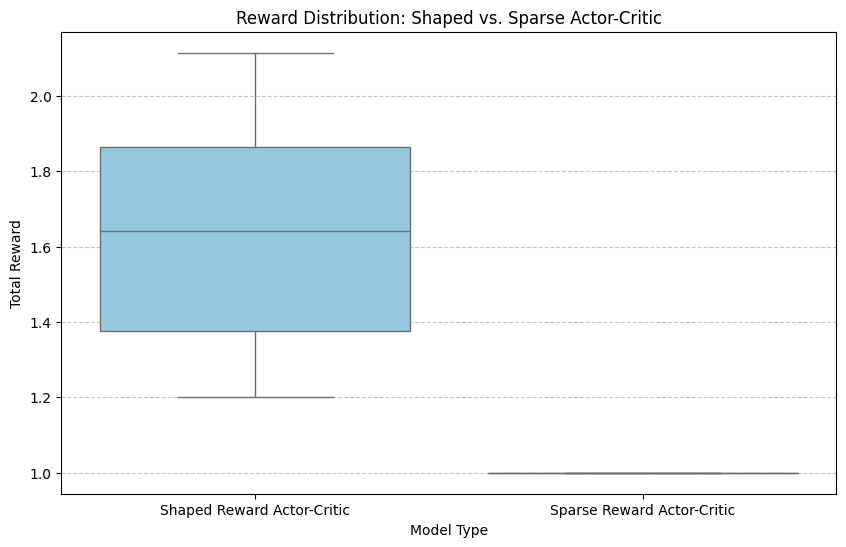

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the reward data into a single DataFrame for easier plotting with seaborn
reward_data_ac = {
    'Reward': r_shaped + r_sparse,
    'Model': ['Shaped Reward Actor-Critic'] * len(r_shaped) + ['Sparse Reward Actor-Critic'] * len(r_sparse)
}
combined_reward_df_ac = pd.DataFrame(reward_data_ac)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Reward', hue='Model', data=combined_reward_df_ac, palette={'Shaped Reward Actor-Critic': 'skyblue', 'Sparse Reward Actor-Critic': 'lightcoral'}, legend=False)
plt.title('Reward Distribution: Shaped vs. Sparse Actor-Critic')
plt.xlabel('Model Type')
plt.ylabel('Total Reward')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Actor-Critic Training Losses: Shaped vs. Sparse

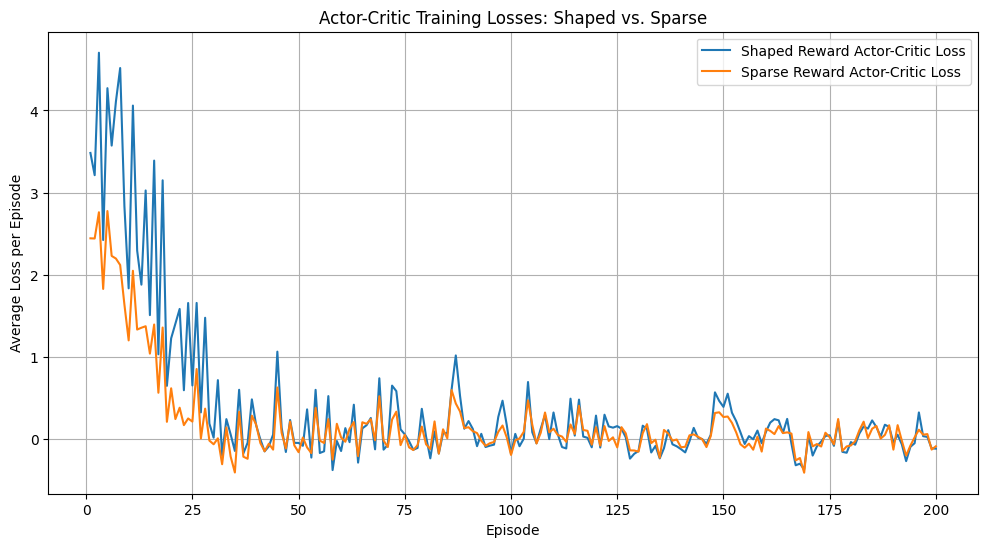

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(losses_shaped_ac)) + 1, losses_shaped_ac, label='Shaped Reward Actor-Critic Loss')
plt.plot(np.arange(len(losses_sparse_ac)) + 1, losses_sparse_ac, label='Sparse Reward Actor-Critic Loss')
plt.xlabel('Episode')
plt.ylabel('Average Loss per Episode')
plt.title('Actor-Critic Training Losses: Shaped vs. Sparse')
plt.legend()
plt.grid(True)
plt.show()

### Actor-Critic Reward Distribution: Shaped vs. Sparse

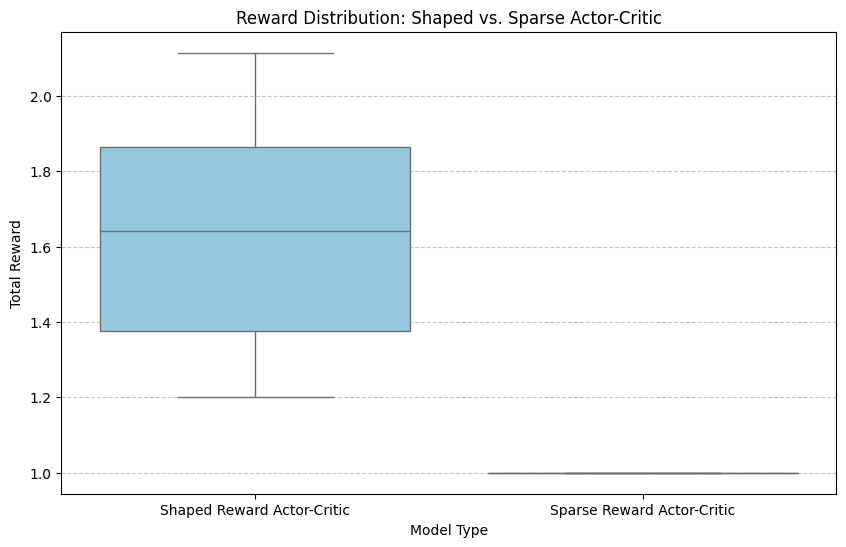

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the reward data into a single DataFrame for easier plotting with seaborn
reward_data_ac = {
    'Reward': r_shaped + r_sparse,
    'Model': ['Shaped Reward Actor-Critic'] * len(r_shaped) + ['Sparse Reward Actor-Critic'] * len(r_sparse)
}
combined_reward_df_ac = pd.DataFrame(reward_data_ac)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Reward', hue='Model', data=combined_reward_df_ac, palette={'Shaped Reward Actor-Critic': 'skyblue', 'Sparse Reward Actor-Critic': 'lightcoral'}, legend=False)
plt.title('Reward Distribution: Shaped vs. Sparse Actor-Critic')
plt.xlabel('Model Type')
plt.ylabel('Total Reward')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

# Assumes MiniChefHatEnv, compute_shaped_reward, and no_shaping are already defined in previous cells.

In [ ]:
# Simple policy (actor) network
class PolicyNetwork(nn.Module):
    def __init__(self, obs_size, action_size, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_size)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
# Simple value (critic) network
class ValueNetwork(nn.Module):
    def __init__(self, obs_size, hidden_size=128):
        super(ValueNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

This code contains Actor Netwrok policy, Adam Optimiser for combined outputs, GAE for stable advantage, action masking to prevent invalid moves, Gradient to maintain training stability.

In [ ]:
class ActorCriticAgent:
    def __init__(self, obs_size, action_size, lr=3e-4, gamma=0.99, lambd=0.95, device="cpu", seed=42):
        self.obs_size = obs_size
        self.action_size = action_size
        self.gamma = gamma
        self.lambd = lambd
        self.device = torch.device(device)
        torch.manual_seed(seed)
        np.random.seed(seed)

        self.actor = PolicyNetwork(obs_size, action_size).to(self.device)
        self.critic = ValueNetwork(obs_size).to(self.device)

        self.optimizer = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr)

    def to_tensor(self, x):
        return torch.tensor(x, dtype=torch.float32, device=self.device)

    def select_action(self, state, valid_actions=None):
        if valid_actions is None or len(valid_actions) == 0:
            valid_actions = list(range(self.action_size))

        state_t = self.to_tensor(state).unsqueeze(0)
        with torch.no_grad():
            logits = self.actor(state_t).squeeze(0)
        # Mask invalid actions
        mask = torch.zeros(self.action_size, dtype=torch.bool, device=self.device)
        mask[valid_actions] = True
        masked_logits = logits.clone()
        invalid_mask = ~mask
        masked_logits[invalid_mask] = -1e9

        dist = torch.distributions.Categorical(logits=masked_logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        value = self.critic(state_t).squeeze(0)
        return int(action.item()), log_prob, value

    def update(self, trajectory):
        # trajectory: list of (state, action, log_prob, value, reward, done)
        states = torch.stack([self.to_tensor(x[0]) for x in trajectory])
        actions = torch.tensor([x[1] for x in trajectory], dtype=torch.int64)
        log_probs = torch.stack([x[2] for x in trajectory])
        values = torch.stack([x[3] for x in trajectory])
        rewards = [x[4] for x in trajectory]
        dones = [x[5] for x in trajectory]

        # Compute returns with GAE
        returns = []
        advantages = []
        gae = 0.0
        next_value = 0.0
        for i in reversed(range(len(rewards))):
            r = rewards[i]
            d = dones[i]
            delta = r + self.gamma * next_value * (1 - d) - values[i].item()
            gae = delta + self.gamma * self.lambd * gae * (1 - d)
            advantages.insert(0, gae)
            next_value = values[i].item()
        returns = [adv + values[i].item() for i, adv in enumerate(advantages)]
        returns_t = torch.tensor(returns, dtype=torch.float32, device=self.device)
        advantages_t = torch.tensor(advantages, dtype=torch.float32, device=self.device)

        # Convert to tensors
        actions_t = actions.to(self.device)
        log_probs_t = log_probs
        values_t = values

        # Losses
        policy_loss = -(log_probs_t * advantages_t).mean()
        value_loss = F.mse_loss(values_t, returns_t)
        entropy_loss = 0  # can add if desired

        loss = policy_loss + value_loss - 0.0 * entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(list(self.actor.parameters()) + list(self.critic.parameters()), 0.5)
        self.optimizer.step()

        return loss.item()

    def save(self, path):
        torch.save({
            "actor": self.actor.state_dict(),
            "critic": self.critic.state_dict(),
            "optimizer": self.optimizer.state_dict(),
        }, path)

    def load(self, path):
        data = torch.load(path, map_location=self.device)
        self.actor.load_state_dict(data["actor"])
        self.critic.load_state_dict(data["critic"])
        self.optimizer.load_state_dict(data["optimizer"])

In [ ]:
# Training loop for two variants (shaped vs sparse)
def train_ac_two_variants(use_shaping=True, max_episodes=200, max_steps=200, gamma=0.99):
    # Create environment (adjust to your actual MiniChefHatEnv)
    env = MiniChefHatEnv(n_players=4, max_cards=5, seed=42)
    obs_size = env.observation_space_n
    action_size = env.action_space.n

    agent = ActorCriticAgent(obs_size, action_size, lr=3e-4, gamma=gamma, lambd=0.95, device="cpu", seed=42)

    episode_rewards = []
    episode_losses = []
    episode_steps = [] # Initialize list to store episode steps

    for ep in range(1, max_episodes+1):
        obs = env.reset()
        state = obs
        total_r = 0.0
        done = False
        prev_hand = env.hands[0]
        trajectory = []

        for t in range(max_steps):
            valid = env.getValidActions()
            action, logp, value = agent.select_action(state, valid)

            next_obs, raw_r, done, info = env.step(action)
            next_state = next_obs

            # Reward shaping
            if use_shaping:
                curr_hand = env.hands[0]
                action_valid = action in valid
                played = max(0, prev_hand - curr_hand)
                reward = shaped_reward(
                    raw_reward=raw_r,
                    prev_hand_size=prev_hand,
                    curr_hand_size=curr_hand,
                    action_was_valid=action_valid,
                    played_card_count=played,
                    is_done=done,
                    agent_finishing_position=None,
                    n_players=4,
                    shaping_config=None
                )
                prev_hand = curr_hand
            else:
                reward = raw_r

            trajectory.append((state, action, logp, value, reward, float(done)))
            state = next_state
            total_r += reward

            if done:
                break

        loss = agent.update(trajectory)
        episode_rewards.append(total_r)
        episode_losses.append(loss)
        episode_steps.append(t + 1) # Store the number of steps for this episode

        if ep % 20 == 0 or ep == 1:
            print(f"[{'shaped' if use_shaping else 'sparse'} AC] Ep {ep:>4}/{max_episodes} | Reward: {total_r:>7.3f} | Loss: {loss:.4f} | Steps: {t+1}")

    model_path = f"results/actor_critic_{'shaped' if use_shaping else 'sparse'}.pth"
    agent.save(model_path)
    print("Model saved to", model_path)
    return episode_rewards, episode_losses, episode_steps # Return steps as well

In [ ]:
# Run with lower gamma (e.g., 0.9)
import os
os.makedirs("results", exist_ok=True)

print("Starting training with lower gamma (0.9): Shaped variant (Actor-Critic)")
r_shaped_low_gamma, losses_shaped_ac_low_gamma, steps_shaped_ac_low_gamma = train_ac_two_variants(use_shaping=True, max_episodes=200, max_steps=200, gamma=0.9)

print("Starting training with lower gamma (0.9): Sparse variant (Actor-Critic)")
r_sparse_low_gamma, losses_sparse_ac_low_gamma, steps_sparse_ac_low_gamma = train_ac_two_variants(use_shaping=False, max_episodes=200, max_steps=200, gamma=0.9)

Starting training with lower gamma (0.9): Shaped variant (Actor-Critic)
[shaped AC] Ep    1/200 | Reward:   1.415 | Loss: 3.2446 | Steps: 2
[shaped AC] Ep   20/200 | Reward:   1.415 | Loss: 1.1216 | Steps: 2
[shaped AC] Ep   40/200 | Reward:   1.270 | Loss: 0.1703 | Steps: 2
[shaped AC] Ep   60/200 | Reward:   1.565 | Loss: -0.0366 | Steps: 5
[shaped AC] Ep   80/200 | Reward:   1.834 | Loss: 0.0030 | Steps: 5
[shaped AC] Ep  100/200 | Reward:   2.014 | Loss: -0.2001 | Steps: 6
[shaped AC] Ep  120/200 | Reward:   2.014 | Loss: 0.2421 | Steps: 6
[shaped AC] Ep  140/200 | Reward:   1.415 | Loss: -0.0648 | Steps: 2
[shaped AC] Ep  160/200 | Reward:   1.784 | Loss: 0.2266 | Steps: 4
[shaped AC] Ep  180/200 | Reward:   1.934 | Loss: -0.1524 | Steps: 7
[shaped AC] Ep  200/200 | Reward:   1.415 | Loss: 0.0747 | Steps: 2
Model saved to results/actor_critic_shaped.pth
Starting training with lower gamma (0.9): Sparse variant (Actor-Critic)
[sparse AC] Ep    1/200 | Reward:   1.000 | Loss: 2.2047 

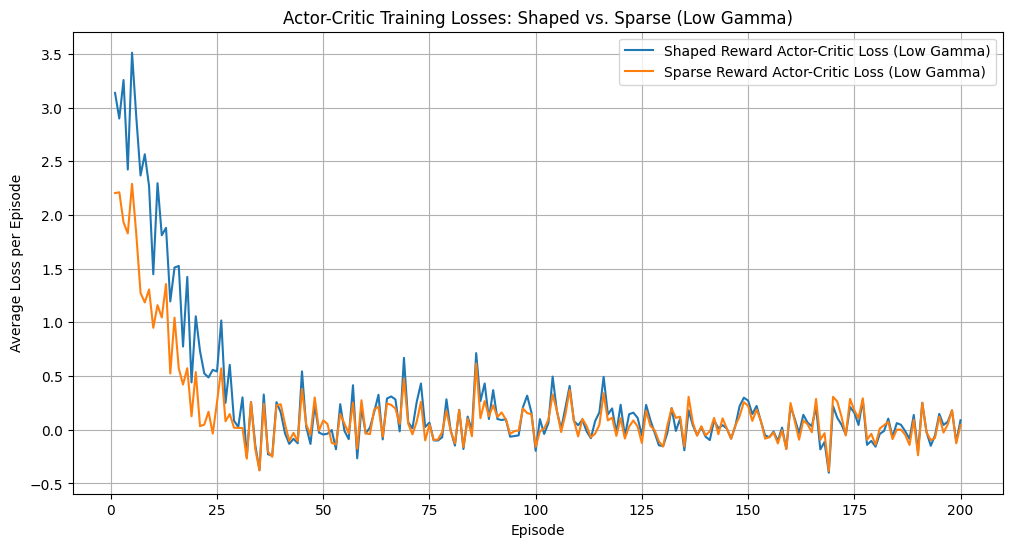

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(losses_shaped_ac_low_gamma)) + 1, losses_shaped_ac_low_gamma, label='Shaped Reward Actor-Critic Loss (Low Gamma)')
plt.plot(np.arange(len(losses_sparse_ac_low_gamma)) + 1, losses_sparse_ac_low_gamma, label='Sparse Reward Actor-Critic Loss (Low Gamma)')
plt.xlabel('Episode')
plt.ylabel('Average Loss per Episode')
plt.title('Actor-Critic Training Losses: Shaped vs. Sparse (Low Gamma)')
plt.legend()
plt.grid(True)
plt.show()

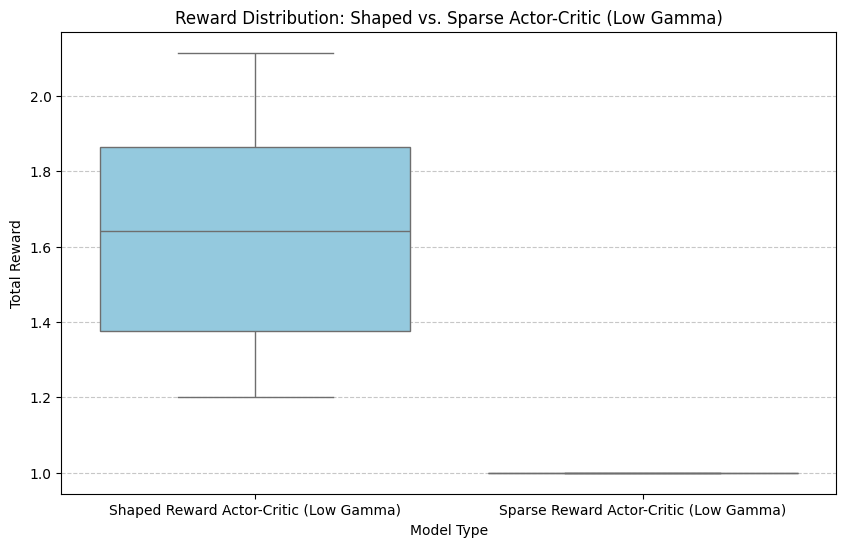

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the reward data into a single DataFrame for easier plotting with seaborn
reward_data_ac_low_gamma = {
    'Reward': r_shaped_low_gamma + r_sparse_low_gamma,
    'Model': ['Shaped Reward Actor-Critic (Low Gamma)'] * len(r_shaped_low_gamma) + ['Sparse Reward Actor-Critic (Low Gamma)'] * len(r_sparse_low_gamma)
}
combined_reward_df_ac_low_gamma = pd.DataFrame(reward_data_ac_low_gamma)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Reward', hue='Model', data=combined_reward_df_ac_low_gamma, palette={'Shaped Reward Actor-Critic (Low Gamma)': 'skyblue', 'Sparse Reward Actor-Critic (Low Gamma)': 'lightcoral'}, legend=False)
plt.title('Reward Distribution: Shaped vs. Sparse Actor-Critic (Low Gamma)')
plt.xlabel('Model Type')
plt.ylabel('Total Reward')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from scipy import stats

# Perform independent two-sample t-test
t_stat, p_value = stats.ttest_ind(r_shaped_low_gamma, r_sparse_low_gamma)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3e}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("There is a statistically significant difference in rewards between the shaped and sparse reward Actor-Critic models (low gamma) with auxiliary reward.")
else:
    print(f"Since the p-value ({p_value:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in rewards between the shaped and sparse reward Actor-Critic models (low gamma) with auxiliary reward.")

T-statistic: 33.370
P-value: 2.181e-117
Since the p-value (2.181e-117) is less than the significance level (0.05), we reject the null hypothesis.
There is a statistically significant difference in rewards between the shaped and sparse reward Actor-Critic models (low gamma) with auxiliary reward.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


### Reward Distribution (After Auxiliary Reward Implementation)

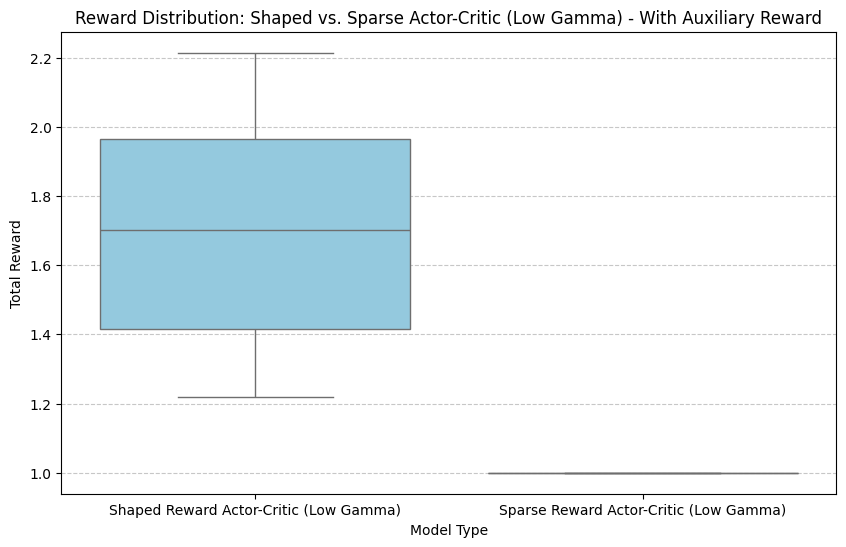

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the reward data into a single DataFrame for easier plotting with seaborn
reward_data_ac_low_gamma = {
    'Reward': r_shaped_low_gamma + r_sparse_low_gamma,
    'Model': ['Shaped Reward Actor-Critic (Low Gamma)'] * len(r_shaped_low_gamma) + ['Sparse Reward Actor-Critic (Low Gamma)'] * len(r_sparse_low_gamma)
}
combined_reward_df_ac_low_gamma = pd.DataFrame(reward_data_ac_low_gamma)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Reward', hue='Model', data=combined_reward_df_ac_low_gamma, palette={'Shaped Reward Actor-Critic (Low Gamma)': 'skyblue', 'Sparse Reward Actor-Critic (Low Gamma)': 'lightcoral'}, legend=False)
plt.title('Reward Distribution: Shaped vs. Sparse Actor-Critic (Low Gamma) - With Auxiliary Reward')
plt.xlabel('Model Type')
plt.ylabel('Total Reward')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Loss Progression (After Auxiliary Reward Implementation)

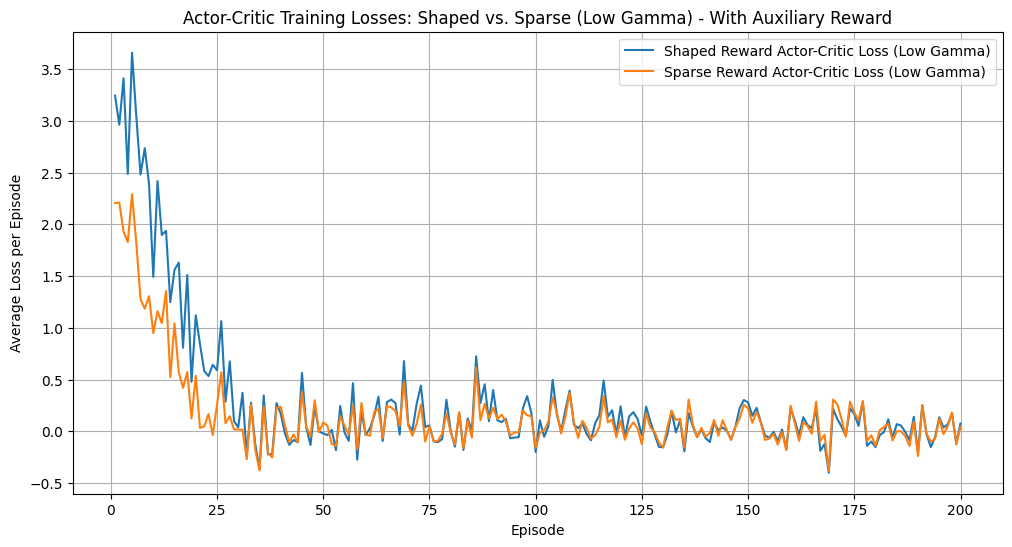

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(losses_shaped_ac_low_gamma)) + 1, losses_shaped_ac_low_gamma, label='Shaped Reward Actor-Critic Loss (Low Gamma)')
plt.plot(np.arange(len(losses_sparse_ac_low_gamma)) + 1, losses_sparse_ac_low_gamma, label='Sparse Reward Actor-Critic Loss (Low Gamma)')
plt.xlabel('Episode')
plt.ylabel('Average Loss per Episode')
plt.title('Actor-Critic Training Losses: Shaped vs. Sparse (Low Gamma) - With Auxiliary Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\n--- Average Step Counts (Gamma=0.9) ---")
print(f"Shaped Reward Actor-Critic (Gamma=0.9) Average Steps: {np.mean(steps_shaped_ac_low_gamma):.2f}")
print(f"Sparse Reward Actor-Critic (Gamma=0.9) Average Steps: {np.mean(steps_sparse_ac_low_gamma):.2f}")


--- Average Step Counts (Gamma=0.9) ---
Shaped Reward Actor-Critic (Gamma=0.9) Average Steps: 4.64
Sparse Reward Actor-Critic (Gamma=0.9) Average Steps: 4.64


In [ ]:
print("\n--- Average Step Counts ---")
print(f"Shaped Reward Actor-Critic Average Steps: {np.mean(steps_shaped_ac_low_gamma):.2f}")
print(f"Sparse Reward Actor-Critic Average Steps: {np.mean(steps_sparse_ac_low_gamma):.2f}")


--- Average Step Counts ---
Shaped Reward Actor-Critic Average Steps: 4.64
Sparse Reward Actor-Critic Average Steps: 4.64


Code was generated by ChatGPT, Microsoft Co-pilot and Gemini, then edited by me.